In [ ]:
!pip install datasets[audio] librosa transformers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Speaker-Recognition-using-ResNet-Embeddings

/content/drive/MyDrive/Speaker-Recognition-using-ResNet-Embeddings


# Data for HuggingFace
we filter out the data we want around 50 speakers that had 500 audio records and have it to local device so we dont have to stream from hugging face.

This section is for demonstrate how we do it, but if for data loading and preprocess, you don't have to run it

In [ ]:
from datasets import load_dataset

dataset = load_dataset("acul3/voxceleb2", split="train",streaming=True)

README.md:   0%|          | 0.00/489 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/215 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/215 [00:00<?, ?it/s]

Take one example to see how audio works

In [ ]:
sample = next(iter(dataset))
print(sample)
audio = sample["audio_path"]

array = audio["array"]
sr = audio["sampling_rate"]

print(array.shape)
print(sr)

RuntimeError: Could not load libtorchcodec. Likely causes:
          1. FFmpeg is not properly installed in your environment. We support
             versions 4, 5, 6, 7, and 8, and we attempt to load libtorchcodec
             for each of those versions. Errors for versions not installed on
             your system are expected; only the error for your installed FFmpeg
             version is relevant. On Windows, ensure you've installed the
             "full-shared" version which ships DLLs.
          2. The PyTorch version (2.8.0) is not compatible with
             this version of TorchCodec. Refer to the version compatibility
             table:
             https://github.com/pytorch/torchcodec?tab=readme-ov-file#installing-torchcodec.
          3. Another runtime dependency; see exceptions below.

        The following exceptions were raised as we tried to load libtorchcodec:
        
[start of libtorchcodec loading traceback]
FFmpeg version 8:
Traceback (most recent call last)

In [ ]:
from IPython.display import Audio
Audio(array, rate=sr)

Count speakers and the number of audio files per speaker (already save to json and csv files)

In [ ]:
import pandas as pd
from collections import Counter

# speakers = set()
# speaker_count = Counter()

# for ex in dataset:
#     speakers.add(ex["speaker_id"])
#     speaker_count[ex["speaker_id"]] += 1

df = pd.read_csv("speaker_count.csv")
speaker_count = Counter(
    dict(zip(df["speaker_id"], df["count"]))
)


In [ ]:
counts = list(speaker_count.values())
print("num speakers:", len(counts))
print("min:", min(counts))
print("max:", max(counts))
print("avg:", sum(counts)/len(counts))

num speakers: 3232
min: 1
max: 500
avg: 143.2085396039604




* Filter speakers with insufficient data  (<500 utterances).  
* Create speaker-to-id and id-to-speaker
* count distribution after filtering.




In [ ]:
import numpy as np

# Original distribution
counts = np.array(list(speaker_count.values()))

print("Before filtering:")
print(np.percentile(counts, [25, 50, 75, 90, 95]))

# Filter speakers
MIN_PER_SPEAKER = 500

valid_speakers = [
    spk for spk, count in speaker_count.items()
    if count >= MIN_PER_SPEAKER
]

valid_speakers = sorted(valid_speakers)

speaker2id = {spk: i for i, spk in enumerate(valid_speakers)}
id2speaker = {i: spk for spk, i in speaker2id.items()}

print("valid speakers:", len(valid_speakers))

# Distribution after filtering
filtered_counts = np.array(
    [speaker_count[spk] for spk in valid_speakers]
)

print("After filtering:")
df = pd.DataFrame({
    "speaker_id": valid_speakers,
    "count": [speaker_count[s] for s in valid_speakers]
})

print(df["count"].describe())

Before filtering:
[ 35.   92.  214.  374.9 482. ]
valid speakers: 1532
After filtering:
count    1532.000000
mean      257.360966
std       127.098144
min       100.000000
25%       148.000000
50%       224.500000
75%       351.250000
max       500.000000
Name: count, dtype: float64


Save speaker_count, speaker2id, id2speaker to files

In [ ]:
# import json

# speaker_count_df = pd.DataFrame({
#     "speaker_id": list(speaker_count.keys()),
#     "count": list(speaker_count.values())
# })

# speaker_count_df = speaker_count_df.sort_values(
#     "count",
#     ascending=False
# )

# speaker_count_df.to_csv(
#     "speaker_count.csv",
#     index=False
# )

# with open("speaker2id.json", "w") as f:
#     json.dump(speaker2id, f, indent=2)

# with open("id2speaker.json", "w") as f:
#     json.dump(id2speaker, f, indent=2)

Filter out non-English recordings and take 50 speakers who had 500 audio record

In [ ]:
valid_speakers = set(valid_speakers)[:50]

dataset = dataset.filter(
    lambda ex:
        ex["language"] == "en"
        and ex["speaker_id"] in valid_speakers
)

In [ ]:
from datasets import Dataset
import gc

# Skip the first 18000 examples that have already been saved
dataset2 = dataset.skip(18000)

saved_data = []
chunk_id = 6

for i, ex in enumerate(dataset2):

    if i % 1000 == 0:
        print(f"Processed {i} examples | Saved: {len(saved_data)}")

    saved_data.append({
        "audio_path": ex["audio_path"],
        "speaker_id": ex["speaker_id"],
        "label": speaker2id[ex["speaker_id"]]
    })

    if len(saved_data) == 3000:

        print(f"Saving chunk {chunk_id}...")

        hf_dataset = Dataset.from_list(saved_data)

        hf_dataset.save_to_disk(
            f"speaker_chunks/chunk_{chunk_id:03d}"
        )

        saved_data = []
        gc.collect()

        print("RAM released.")

        chunk_id += 1


# Save the remaining examples
if len(saved_data) > 0:

    print(f"Saving final chunk {chunk_id}...")

    hf_dataset = Dataset.from_list(saved_data)

    hf_dataset.save_to_disk(
        f"speaker_chunks/chunk_{chunk_id:03d}"
    )

    print("Done!")

# Data Preprocessing
loading data from local and Preprocess

In [ ]:
from datasets import load_from_disk, concatenate_datasets, Audio
import glob
from datasets import disable_caching

# disable caching so no addition file are saved in drives

disable_caching()

# loading data

chunk_paths = sorted(glob.glob("speaker_chunks/chunk_*"))

chunks = []
for path in chunk_paths:
    ds = load_from_disk(path)
    ds = ds.cast_column("audio_path", Audio(sampling_rate=16000))
    chunks.append(ds)

full_dataset = concatenate_datasets(chunks)

In [ ]:
# split into train, dev, and test

split = full_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split["train"]

temp = split["test"].train_test_split(test_size=0.5, seed=42)
dev_dataset = temp["train"]
test_dataset = temp["test"]

print(len(train_dataset), len(dev_dataset), len(test_dataset))

20000 2500 2500


Prepocess data by using Dataset_Builder script

In [ ]:
from dataset import Dataset_Builder

# try the training set first

config = {"shortest_duration": 4.0} # (optional)

train_builder = Dataset_Builder(train_dataset, **config)
train_builder.filter()
train_builder.preprocess()

Duration of cropped log-mel spectograms (input):  4.0  seconds


Filter:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/19231 [00:00<?, ? examples/s]

NameError: name 'builder' is not defined

In [ ]:
# Also do it for dev, and train

dev_builder = Dataset_Builder(dev_dataset, **config)
dev_builder.filter()
dev_builder.preprocess()

test_builder = Dataset_Builder(test_dataset, **config)
test_builder.filter()
test_builder.preprocess()

Duration of cropped log-mel spectograms (input):  4.0  seconds


Filter:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2402 [00:00<?, ? examples/s]

Duration of cropped log-mel spectograms (input):  4.0  seconds


Filter:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2407 [00:00<?, ? examples/s]

In [ ]:
# get the preprocess data

train_dataset = train_builder.get_dataset()
dev_dataset = dev_builder.get_dataset()
test_dataset = test_builder.get_dataset()

print(len(train_dataset), len(dev_dataset), len(test_dataset))

19231 2402 2407


Demonstrate the log-Mel spectrogram before and after preprocessing. During preprocessing, the spectrogram is randomly cropped, resized, and normalized before being fed into the ResNet model.

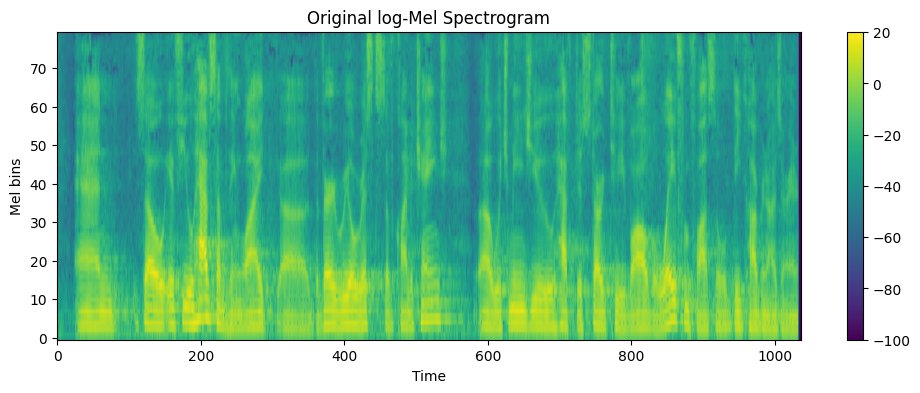

In [ ]:
import torchaudio
import matplotlib.pyplot as plt

example = dev_dataset[6]
target_sr = 16000

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=target_sr,
    n_fft=400,
    hop_length=160,
    n_mels=80
)

to_db = torchaudio.transforms.AmplitudeToDB()

samples = example["audio_path"].get_all_samples()

waveform = samples.data.float()
sr = samples.sample_rate

if waveform.ndim == 1:
    waveform = waveform.unsqueeze(0)

if sr != target_sr:
    waveform = torchaudio.functional.resample(
        waveform,
        orig_freq=sr,
        new_freq=target_sr
    )

mel = mel_transform(waveform)
log_mel = to_db(mel).squeeze(0)     # [80, T]

plt.figure(figsize=(12,4))
plt.imshow(log_mel.numpy(),origin="lower",aspect="auto")

plt.title("Original log-Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel bins")
plt.colorbar()
plt.show()

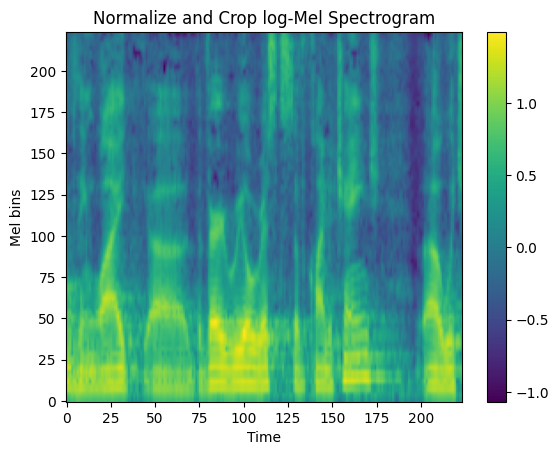

In [ ]:
crop = example["log_mel"][0]
plt.imshow(crop,origin="lower",aspect="auto")

plt.title("Normalize and Crop log-Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel bins")
plt.colorbar()
plt.show()

## Create DataLoaders

Create a custom collate function to convert the data into tensors. Then, build the train, dev, and test data loaders and check that the batch dimensions match the expected input format.

In [ ]:
import torch

def collate_fn(batch):
    log_mels = torch.stack([x["log_mel"]for x in batch])
    labels = torch.tensor([x["label"] for x in batch],dtype=torch.long)

    return {
        "log_mel": log_mels,
        "labels": labels
        }

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    collate_fn=collate_fn
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=32,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    collate_fn=collate_fn
)

In [ ]:
batch = next(iter(train_loader))

print(batch["log_mel"].shape)  # [B, 1, 80, T]
print(batch["labels"].shape)          # [B]

torch.Size([32, 3, 224, 224])
torch.Size([32])
